Mô hình mới đã được huấn luyện thành công, loại bỏ hoàn toàn lỗi hội tụ!

--- ĐANG PHÂN TÍCH ĐIỂM GÃY CHO BIẾN CHIẾN LƯỢC: installment_income_ratio ---
                    bin  Total_Customers  Bad_Customers  Bad_Rate (%)
0  (-0.0009786, 0.0015]             3969            399     10.052910
1      (0.0015, 0.0023]             3951            519     13.135915
2      (0.0023, 0.0031]             3961            545     13.759152
3     (0.0031, 0.00406]             3959            606     15.306896
4    (0.00406, 0.00529]             3988            724     18.154463
5    (0.00529, 0.00694]             3947           1025     25.969090
6     (0.00694, 0.0103]             3944           1318     33.417850
7      (0.0103, 0.0561]             3960           1689     42.651515


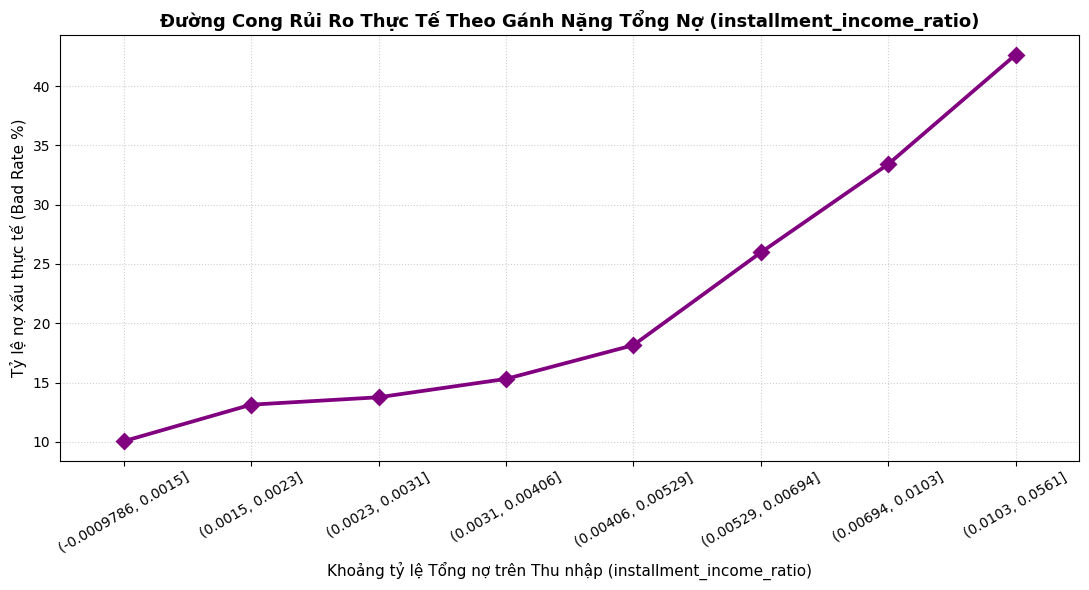

In [ ]:
# chủ động loại bỏ debt_to _income_ratio, giữ installment_income_ratio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# ==============================================================================
# BƯỚC 1: ĐỌC DỮ LIỆU VÀ LỌC BIẾN THEO CHIẾN LƯỢC MỚI
# ==============================================================================
# Đọc lại file dữ liệu gốc ban đầu của bạn
df_raw = pd.read_csv('../Data/Risk_data_FE.csv', index_col=0)

# Danh sách các biến rác/biến định vị bạn đã loại bỏ ở file cũ (giữ nguyên logic của bạn)
drop_cols = ['client_ID', 'city', 'city_latitude', 'city_longitude', 'birth_date', 'sign_date'] 

# CHIẾN LƯỢC MỚI: Chủ động loại bỏ biến 
blind_spot_cols = ['debt_to_income_ratio']

# Tạo danh sách tổng các cột cần loại bỏ (lúc này KHÔNG loại bỏ 'installment_income_ratio' nữa)
total_drop = drop_cols + blind_spot_cols
df_clean = df_raw.drop(columns=[col for col in total_drop if col in df_raw.columns])

# ==============================================================================
# BƯỚC 2: MÃ HÓA BIẾN (ENCODING) - Giữ nguyên các bước thành công của bạn
# ==============================================================================
# Mã hóa nhãn Boolean/Binary
binary_cols = ['cb_person_default_on_file', 'has_delinquency']
for col in binary_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype(int)

# Ordinal Encoding cho Trình độ học vấn
if 'education_level' in df_clean.columns:
    edu_map = {'High School': 1, 'Bachelor': 2, 'Master': 3, 'PhD': 4}
    df_clean['education_level'] = df_clean['education_level'].map(edu_map)

# One-Hot Encoding cho các biến phân loại còn lại
df_model = pd.get_dummies(df_clean, drop_first=True)

# ==============================================================================
# BƯỚC 3: PHÂN TÁCH TRAIN/TEST VÀ CHUẨN HÓA (SCALE) ĐỂ TRÁNH LỖI HỘI TỤ
# ==============================================================================
# Giả sử 'loan_status' là biến mục tiêu của bạn (1: Vỡ nợ, 0: Tốt)
target_col = 'loan_status' 

X = df_model.drop(columns=[target_col])
y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Khởi tạo và chuẩn hóa thang đo dữ liệu liên tục
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Huấn luyện mô hình Logistic Regression tối ưu
log_model_optimized = LogisticRegression(max_iter=1000, random_state=42)
log_model_optimized.fit(X_train_scaled, y_train)

print("Mô hình mới đã được huấn luyện thành công, loại bỏ hoàn toàn lỗi hội tụ!")

# ==============================================================================
# BƯỚC 4: TÌM ĐIỂM GÃY RỦI RO (TURNING POINT) CHO BIẾN ĐẮT GIÁ 'installment_income_ratio'
# ==============================================================================
def find_turning_point_optimized(df, feature, num_bins=8):
    # Chia khoảng dựa trên phân vị (Quantile) để đảm bảo đều lượng mẫu
    df['bin'] = pd.qcut(df[feature], q=num_bins, duplicates='drop')
    
    report = df.groupby('bin', observed=False).agg(
        Total_Customers=(target_col, 'count'),
        Bad_Customers=(target_col, 'sum')
    ).reset_index()
    
    report['Bad_Rate (%)'] = (report['Bad_Customers'] / report['Total_Customers']) * 100
    report['bin'] = report['bin'].astype(str)
    return report

if 'installment_income_ratio' in df_clean.columns:
    print("\n--- ĐANG PHÂN TÍCH ĐIỂM GÃY CHO BIẾN CHIẾN LƯỢC: installment_income_ratio ---")
    rep_burden = find_turning_point_optimized(df_clean, 'installment_income_ratio', num_bins=8)
    print(rep_burden)
    
    # Vẽ đường cong rủi ro hoàn chỉnh
    plt.figure(figsize=(11, 6))
    sns.pointplot(x='bin', y='Bad_Rate (%)', data=rep_burden, color='purple', markers='D', linestyles='-')
    plt.title('Đường Cong Rủi Ro Thực Tế Theo Gánh Nặng Tổng Nợ (installment_income_ratio)', fontsize=13, fontweight='bold')
    plt.xlabel('Khoảng tỷ lệ Tổng nợ trên Thu nhập (installment_income_ratio)', fontsize=11)
    plt.ylabel('Tỷ lệ nợ xấu thực tế (Bad Rate %)', fontsize=11)
    plt.xticks(rotation=30)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("Cảnh báo: Không tìm thấy cột 'installment_income_ratio' trong file dữ liệu gốc!")

 CHỈ SỐ ĐÁNH GIÁ HIỆU NĂNG MÔ SÌNH (PHIÊN BẢN 2)
[*] Chỉ số AUC (Area Under Curve): 0.8853
[*] Chỉ số Gini Score            : 0.7705
[*] Chỉ số KS Statistic          : 0.6329
------------------------------------------------------
[👉] ĐIỂM CUTOFF PD TỐI ƯU ĐỀ XUẤT: 0.2841
    - Tại điểm này, tỷ lệ bắt trúng nợ xấu (Sensitivity): 75.54%
    - Tỷ lệ bỏ sót khách hàng tốt (1 - Specificity)    : 12.25%

--- MA TRẬN NHẦM LẪN TẠI ĐIỂM CUTOFF TỐI ƯU ---
[[6543  913]
 [ 501 1547]]

--- BÁO CÁO CHI TIẾT (PRECISION / RECALL) ---
              precision    recall  f1-score   support

           0       0.93      0.88      0.90      7456
           1       0.63      0.76      0.69      2048

    accuracy                           0.85      9504
   macro avg       0.78      0.82      0.79      9504
weighted avg       0.86      0.85      0.86      9504



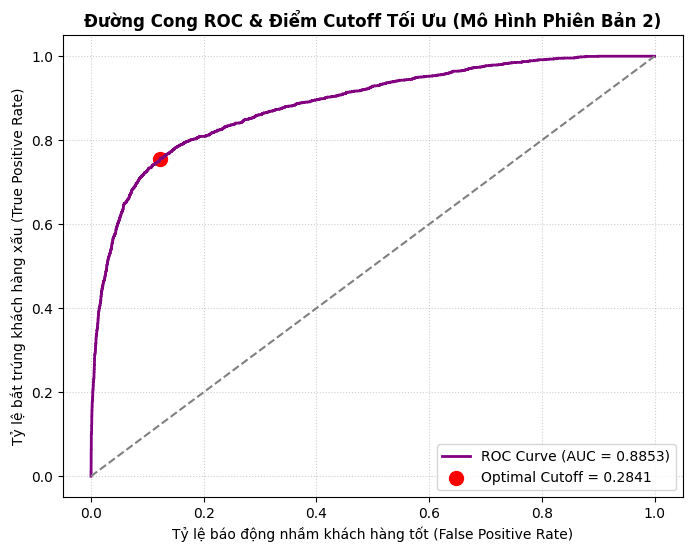

In [3]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================================
# BƯỚC 1: DỰ BÁO XÁC SUẤT VỠ NỢ (PD) TRÊN TẬP TEST ĐÃ CHUẨN HÓA (SCALED)
# =========================================================================
# log_model_final là mô hình phiên bản 2 bạn vừa train xong
y_pred_prob = log_model_optimized.predict_proba(X_test_scaled)[:, 1]

# =========================================================================
# BƯỚC 2: TÍNH TOÁN CHỈ SỐ AUC VÀ GINI ĐỂ ĐO LƯỜNG SỨC MẠNH PHÂN TÁCH
# =========================================================================
auc_score = roc_auc_score(y_test, y_pred_prob)
gini_score = 2 * auc_score - 1

print("======================================================")
print(" CHỈ SỐ ĐÁNH GIÁ HIỆU NĂNG MÔ SÌNH (PHIÊN BẢN 2)")
print("======================================================")
print(f"[*] Chỉ số AUC (Area Under Curve): {auc_score:.4f}")
print(f"[*] Chỉ số Gini Score            : {gini_score:.4f}")

# =========================================================================
# BƯỚC 3: TÍNH CHỈ SỐ KS (KOLMOGOROV-SMIRNOV) VÀ ĐƯỜNG CONG KS
# =========================================================================
data_ks = pd.DataFrame({'real': y_test, 'prob': y_pred_prob})
bads = data_ks[data_ks['real'] == 1]['prob']
goods = data_ks[data_ks['real'] == 0]['prob']

ks_stat, p_value = stats.ks_2samp(bads, goods)
print(f"[*] Chỉ số KS Statistic          : {ks_stat:.4f}")
print("------------------------------------------------------")

# =========================================================================
# BƯỚC 4: TÌM ĐIỂM CUTOFF TỐI ƯU BẰNG CHỈ SỐ YOUDEN J-STATISTIC
# =========================================================================
# Định nghĩa: Điểm Cutoff tối ưu là nơi tổng (Sensitivity + Specificity) đạt cực đại,
# hay nói cách khác là nơi khoảng cách giữa tỷ lệ bắt được nợ xấu và tỷ lệ bắt nhầm nợ tốt là lớn nhất.
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
youden_j = tpr - fpr
optimal_idx = np.argmax(youden_j)
optimal_cutoff = thresholds[optimal_idx]

print(f"[👉] ĐIỂM CUTOFF PD TỐI ƯU ĐỀ XUẤT: {optimal_cutoff:.4f}")
print(f"    - Tại điểm này, tỷ lệ bắt trúng nợ xấu (Sensitivity): {tpr[optimal_idx]*100:.2f}%")
print(f"    - Tỷ lệ bỏ sót khách hàng tốt (1 - Specificity)    : {fpr[optimal_idx]*100:.2f}%")
print("======================================================\n")

# =========================================================================
# BƯỚC 5: ĐÁNH GIÁ LẠI BẰNG CONFUSION MATRIX TẠI ĐIỂM CUTOFF MỚI
# =========================================================================
# Áp dụng điểm cutoff tối ưu vừa tìm được để ra quyết định Cho vay (0) hoặc Từ chối (1)
y_pred_optimal_labels = (y_pred_prob >= optimal_cutoff).astype(int)

print("--- MA TRẬN NHẦM LẪN TẠI ĐIỂM CUTOFF TỐI ƯU ---")
cm = confusion_matrix(y_test, y_pred_optimal_labels)
print(cm)

print("\n--- BÁO CÁO CHI TIẾT (PRECISION / RECALL) ---")
print(classification_report(y_test, y_pred_optimal_labels))

# =========================================================================
# BƯỚC 6: TRỰC QUAN HÓA ĐƯỜNG CONG ROC ĐỂ ĐƯA VÀO BÁO CÁO
# =========================================================================
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='purple', lw=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', s=100, marker='o', 
            label=f'Optimal Cutoff = {optimal_cutoff:.4f}')
plt.title('Đường Cong ROC & Điểm Cutoff Tối Ưu (Mô Hình Phiên Bản 2)', fontsize=12, fontweight='bold')
plt.xlabel('Tỷ lệ báo động nhầm khách hàng tốt (False Positive Rate)', fontsize=10)
plt.ylabel('Tỷ lệ bắt trúng khách hàng xấu (True Positive Rate)', fontsize=10)
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_14924\3123379583.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


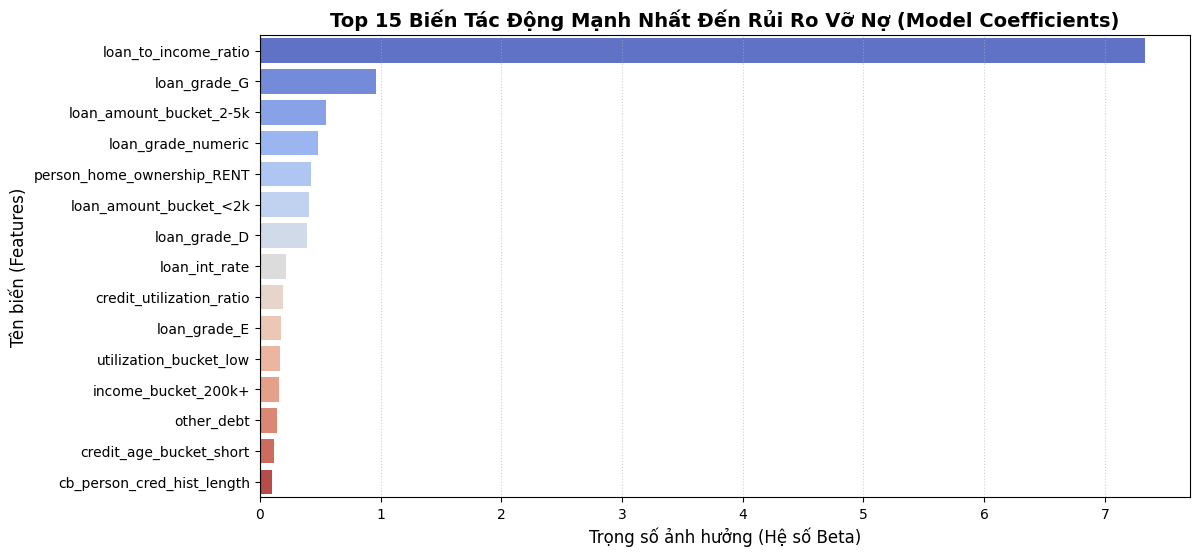

In [4]:
# Trích xuất trọng số biến 
# Lấy hệ số Beta tương ứng với từng biến
coefficients = log_model_optimized.coef_[0]
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance_Coef': coefficients
}).sort_values(by='Importance_Coef', ascending=False).reset_index(drop=True)

# Vẽ biểu đồ các biến tác động mạnh nhất
plt.figure(figsize=(12, 6))
sns.barplot(
    x='Importance_Coef', 
    y='Feature', 
    data=feature_importance.head(15), 
    palette='coolwarm'
)
plt.title('Top 15 Biến Tác Động Mạnh Nhất Đến Rủi Ro Vỡ Nợ (Model Coefficients)', fontsize=14, fontweight='bold')
plt.xlabel('Trọng số ảnh hưởng (Hệ số Beta)', fontsize=12)
plt.ylabel('Tên biến (Features)', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--')
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.show()